In [ ]:
!pip install torchcfm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 131.5 MB/s eta 0:00:00


In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchcfm.models.unet.unet import UNetModelWrapper

##############################################################################
# Simple Patch Embedding (like in ViT)
##############################################################################
class PatchEmbed(nn.Module):
    """
    Splits the (B, C, H, W) feature map into non-overlapping patches and
    embeds each patch to `embed_dim`.
    """
    def __init__(
        self,
        in_channels=3,
        patch_size=4,
        embed_dim=128,
        image_size=(32, 32),
        include_pos_embed=True
    ):
        super().__init__()
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.num_patches_h = image_size[0] // patch_size
        self.num_patches_w = image_size[1] // patch_size
        self.num_patches = self.num_patches_h * self.num_patches_w

        # Patch embedding via Conv2d
        self.patch_embed = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        # Optional learnable positional embeddings
        self.include_pos_embed = include_pos_embed
        if include_pos_embed:
            self.pos_embed = nn.Parameter(
                torch.zeros(1, self.num_patches, embed_dim)
            )
        else:
            self.pos_embed = None

        # Initialize patch embedding weights
        nn.init.xavier_uniform_(self.patch_embed.weight)

    def forward(self, x):
        # x: (B, C, H, W)
        # => (B, E, H', W') after patch_embed
        x = self.patch_embed(x)  # shape: (B, embed_dim, H', W')
        B, E, Hp, Wp = x.shape
        # Flatten
        x = x.view(B, E, Hp * Wp).transpose(1, 2)  # => (B, N, E)
        # Add positional embedding if needed
        if self.pos_embed is not None:
            x = x + self.pos_embed  # (1, N, E) broadcast
        return x


##############################################################################
# Soft clamp
##############################################################################
def soft_clamp(x, clamp_val):
    """Tanh-based clamp: output in [-clamp_val, clamp_val]."""
    return clamp_val * torch.tanh(x / clamp_val)


##############################################################################
# Helper to create a dummy time tensor
##############################################################################
def dummy_time(x, value=0.5):
    """
    Create a (B,)-shaped tensor of `value`, matching x's device and dtype.
    """
    return torch.full(
        (x.shape[0],),
        value,
        device=x.device,
        dtype=x.dtype
    )


##############################################################################
# 1) EBM with a patch-based ViT head
##############################################################################
class EBViTModelWrapper(UNetModelWrapper):
    """
    Energy-Based Model with a patch-based ViT on top of the UNet output.
    Ignores the input time; always feeds a fixed dummy time to the UNet.

    Note: potential() and velocity() now accept (x, t) where t is ignored.
    """

    def __init__(
        self,
        dim=(3, 32, 32),
        num_channels=128,
        num_res_blocks=2,
        channel_mult=[1, 2, 2, 2],
        attention_resolutions="16",
        num_heads=4,
        num_head_channels=64,
        dropout=0.1,
        # UNet flags
        class_cond=False,
        learn_sigma=False,
        use_checkpoint=False,
        use_fp16=False,
        resblock_updown=False,
        use_scale_shift_norm=False,
        use_new_attention_order=False,
        # ViT-specific
        patch_size=4,
        embed_dim=128,
        transformer_nheads=4,
        transformer_nlayers=2,
        include_pos_embed=True,
        # EBM extras
        output_scale=1000.0,
        energy_clamp=None,
        **kwargs
    ):
        super().__init__(
            dim=dim,
            num_channels=num_channels,
            num_res_blocks=num_res_blocks,
            channel_mult=channel_mult,
            attention_resolutions=attention_resolutions,
            num_heads=num_heads,
            num_head_channels=num_head_channels,
            dropout=dropout,
            class_cond=class_cond,
            learn_sigma=learn_sigma,
            use_checkpoint=use_checkpoint,
            use_fp16=use_fp16,
            resblock_updown=resblock_updown,
            use_scale_shift_norm=use_scale_shift_norm,
            use_new_attention_order=use_new_attention_order,
            **kwargs
        )

        self.out_channels = dim[0]
        self.output_scale = output_scale
        self.energy_clamp = energy_clamp

        # 1) PatchEmbed for the UNet output
        self.patch_embed = PatchEmbed(
            in_channels=self.out_channels,
            patch_size=patch_size,
            embed_dim=embed_dim,
            image_size=dim[1:],  # (H, W)
            include_pos_embed=include_pos_embed
        )

        # 2) A small Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=transformer_nheads,
            dim_feedforward=4 * embed_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=transformer_nlayers
        )

        # 3) Final linear => scalar
        self.final_linear = nn.Linear(embed_dim, 1)

    def potential(self, x, t):
        """
        Computes scalar potential V(x,t) => shape (B,).
        Ignores the provided time and always uses a fixed dummy time.
        """
        t_dummy = dummy_time(x, value=0.5)
        # UNet forward: shape (B, C, H, W)
        unet_out = super().forward(t_dummy, x)
        # Patch-embed: (B, N, embed_dim)
        tokens = self.patch_embed(unet_out)
        # Transformer: (B, N, embed_dim)
        encoded = self.transformer_encoder(tokens)
        # Mean-pool across tokens: (B, embed_dim)
        pooled = encoded.mean(dim=1)
        # Final linear to scalar: (B, 1) -> (B,)
        V = self.final_linear(pooled).view(-1)
        V = V * self.output_scale
        if self.energy_clamp is not None:
            V = soft_clamp(V, self.energy_clamp)
        return V

    def velocity(self, x, t):
        """
        Computes -∂V/∂x => shape (B, C, H, W).
        Ignores the provided time.
        """
        with torch.enable_grad():
            x = x.clone().detach().requires_grad_(True)
            V = self.potential(x, t)
            dVdx = torch.autograd.grad(
                outputs=V,
                inputs=x,
                grad_outputs=torch.ones_like(V),
                create_graph=self.training
            )[0]
            return -dVdx

    def forward(self, t, x, return_potential=False, *args, **kwargs):
        """
        Forward pass accepts a time tensor and an input tensor.
        The provided time is ignored (dummy time is used internally).
        If return_potential=True, returns V(x,t); otherwise returns velocity.
        """
        if return_potential:
            return self.potential(x, t)
        else:
            return self.velocity(x, t)


##############################################################################
# 2) EBM with a simple MLP head (SiLU in the hidden layer)
##############################################################################
class EBMLPModelWrapper(UNetModelWrapper):
    """
    Energy-Based Model that extends the UNet code but uses a simple MLP head.
    Ignores the provided time; always feeds a fixed dummy time to the UNet.

    MLP architecture:
        Global average pool -> Linear -> SiLU -> Linear -> scalar V(x,t).
    """

    def __init__(
        self,
        dim=(3, 32, 32),
        num_channels=128,
        num_res_blocks=2,
        channel_mult=[1, 2, 2, 2],
        attention_resolutions="16",
        num_heads=4,
        num_head_channels=64,
        dropout=0.1,
        # UNet flags
        class_cond=False,
        learn_sigma=False,
        use_checkpoint=False,
        use_fp16=False,
        resblock_updown=False,
        use_scale_shift_norm=False,
        use_new_attention_order=False,
        # EBM extras
        output_scale=1000.0,
        energy_clamp=None,
        **kwargs
    ):
        super().__init__(
            dim=dim,
            num_channels=num_channels,
            num_res_blocks=num_res_blocks,
            channel_mult=channel_mult,
            attention_resolutions=attention_resolutions,
            num_heads=num_heads,
            num_head_channels=num_head_channels,
            dropout=dropout,
            class_cond=class_cond,
            learn_sigma=learn_sigma,
            use_checkpoint=use_checkpoint,
            use_fp16=use_fp16,
            resblock_updown=resblock_updown,
            use_scale_shift_norm=use_scale_shift_norm,
            use_new_attention_order=use_new_attention_order,
            **kwargs
        )

        self.out_channels = dim[0]
        self.output_scale = output_scale
        self.energy_clamp = energy_clamp

        # Global average pooling
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # Simple MLP: [Flatten -> Linear -> SiLU -> Linear -> scalar]
        self.mlp = nn.Sequential(
            nn.Flatten(),                     # => (B, C)
            nn.Linear(self.out_channels, self.out_channels),
            nn.SiLU(),
            nn.Linear(self.out_channels, 1)   # => scalar output
        )

    def potential(self, x, t):
        """
        Computes scalar potential V(x,t) => shape (B,).
        Ignores the provided time.
        """
        t_dummy = dummy_time(x, value=0.5)
        # UNet forward: (B, C, H, W)
        unet_out = super().forward(t_dummy, x)
        # Global average pool: (B, C, 1, 1)
        pooled = self.pool(unet_out)
        # MLP: (B, 1) -> (B,)
        V = self.mlp(pooled).view(-1)
        V = V * self.output_scale
        if self.energy_clamp is not None:
            V = soft_clamp(V, self.energy_clamp)
        return V

    def velocity(self, x, t):
        """
        Computes -∂V/∂x => shape (B, C, H, W).
        Ignores the provided time.
        """
        with torch.enable_grad():
            x = x.clone().detach().requires_grad_(True)
            V = self.potential(x, t)
            dVdx = torch.autograd.grad(
                outputs=V,
                inputs=x,
                grad_outputs=torch.ones_like(V),
                create_graph=self.training
            )[0]
            return -dVdx

    def forward(self, t, x, return_potential=False, *args, **kwargs):
        """
        Forward pass accepts a time tensor and an input tensor.
        The provided time is ignored (dummy time is used internally).
        If return_potential=True, returns V(x,t); otherwise returns velocity.
        """
        if return_potential:
            return self.potential(x, t)
        else:
            return self.velocity(x, t)

##############################################################################
# 3) EBM with a single self-attention layer over patches (between MLP and ViT)
##############################################################################
class EBAttnModelWrapper(UNetModelWrapper):
    """
    Energy-Based Model with a single multi-head self-attention layer over
    patch tokens, sitting between EBMLPModelWrapper (no spatial reasoning)
    and EBViTModelWrapper (full Transformer encoder).

    Pipeline:
        UNet -> PatchEmbed -> Single MHA layer -> mean pool -> Linear -> V(x)
    """

    def __init__(
        self,
        dim=(3, 32, 32),
        num_channels=128,
        num_res_blocks=2,
        channel_mult=[1, 2, 2, 2],
        attention_resolutions="16",
        num_heads=4,
        num_head_channels=64,
        dropout=0.1,
        # UNet flags
        class_cond=False,
        learn_sigma=False,
        use_checkpoint=False,
        use_fp16=False,
        resblock_updown=False,
        use_scale_shift_norm=False,
        use_new_attention_order=False,
        # Attention-specific
        patch_size=4,
        embed_dim=128,
        attn_nheads=4,
        include_pos_embed=True,
        # EBM extras
        output_scale=1000.0,
        energy_clamp=None,
        **kwargs
    ):
        super().__init__(
            dim=dim,
            num_channels=num_channels,
            num_res_blocks=num_res_blocks,
            channel_mult=channel_mult,
            attention_resolutions=attention_resolutions,
            num_heads=num_heads,
            num_head_channels=num_head_channels,
            dropout=dropout,
            class_cond=class_cond,
            learn_sigma=learn_sigma,
            use_checkpoint=use_checkpoint,
            use_fp16=use_fp16,
            resblock_updown=resblock_updown,
            use_scale_shift_norm=use_scale_shift_norm,
            use_new_attention_order=use_new_attention_order,
            **kwargs
        )

        self.out_channels = dim[0]
        self.output_scale = output_scale
        self.energy_clamp = energy_clamp

        # 1) PatchEmbed — same as ViT variant
        self.patch_embed = PatchEmbed(
            in_channels=self.out_channels,
            patch_size=patch_size,
            embed_dim=embed_dim,
            image_size=dim[1:],
            include_pos_embed=include_pos_embed
        )

        # 2) Single self-attention layer (no feedforward, no layernorm stack)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=attn_nheads,
            dropout=dropout,
            batch_first=True
        )
        self.attn_norm = nn.LayerNorm(embed_dim)

        # 3) Linear -> scalar
        self.final_linear = nn.Linear(embed_dim, 1)

    def potential(self, x, t):
        t_dummy = dummy_time(x, value=0.5)
        # UNet forward: (B, C, H, W)
        unet_out = super().forward(t_dummy, x)
        # Patch embed: (B, N, embed_dim)
        tokens = self.patch_embed(unet_out)
        # Single self-attention with residual + layernorm
        attn_out, _ = self.attn(tokens, tokens, tokens)
        tokens = self.attn_norm(tokens + attn_out)
        # Mean pool: (B, embed_dim)
        pooled = tokens.mean(dim=1)
        # Scalar: (B,)
        V = self.final_linear(pooled).view(-1)
        V = V * self.output_scale
        if self.energy_clamp is not None:
            V = soft_clamp(V, self.energy_clamp)
        return V

    def velocity(self, x, t):
        with torch.enable_grad():
            x = x.clone().detach().requires_grad_(True)
            V = self.potential(x, t)
            dVdx = torch.autograd.grad(
                outputs=V,
                inputs=x,
                grad_outputs=torch.ones_like(V),
                create_graph=self.training
            )[0]
            return -dVdx

    def forward(self, t, x, return_potential=False, *args, **kwargs):
        if return_potential:
            return self.potential(x, t)
        else:
            return self.velocity(x, t)


##############################################################################
# 4) Modern Hopfield energy head (UNet backbone + Hopfield scalar)
##############################################################################
class EBHopfieldModelWrapper(UNetModelWrapper):
    """
    Modern Hopfield energy head on top of the UNet backbone.

    V(x) = -(1/β) * logsumexp(β · q(x) · Ξᵀ)

    The gradient -∂V/∂x is a softmax-weighted average of the memory prototypes
    Ξ (via the chain rule through q), so it naturally points toward the nearest
    stored pattern.  Multi-modal by construction; no convexity constraint.

    Reference: Ramsauer et al. (2020) "Hopfield Networks is All You Need".
    """

    def __init__(
        self,
        dim=(3, 32, 32),
        num_channels=128,
        num_res_blocks=2,
        channel_mult=[1, 2, 2, 2],
        attention_resolutions="16",
        num_heads=4,
        num_head_channels=64,
        dropout=0.1,
        class_cond=False,
        learn_sigma=False,
        use_checkpoint=False,
        use_fp16=False,
        resblock_updown=False,
        use_scale_shift_norm=False,
        use_new_attention_order=False,
        n_memories=512,
        embed_dim=128,
        hopfield_beta=8.0,
        output_scale=1000.0,
        energy_clamp=None,
        **kwargs
    ):
        super().__init__(
            dim=dim,
            num_channels=num_channels,
            num_res_blocks=num_res_blocks,
            channel_mult=channel_mult,
            attention_resolutions=attention_resolutions,
            num_heads=num_heads,
            num_head_channels=num_head_channels,
            dropout=dropout,
            class_cond=class_cond,
            learn_sigma=learn_sigma,
            use_checkpoint=use_checkpoint,
            use_fp16=use_fp16,
            resblock_updown=resblock_updown,
            use_scale_shift_norm=use_scale_shift_norm,
            use_new_attention_order=use_new_attention_order,
            **kwargs
        )
        self.out_channels = dim[0]
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.query_proj = nn.Linear(self.out_channels, embed_dim)
        self.memories = nn.Parameter(torch.randn(n_memories, embed_dim) * 0.02)
        self.hopfield_beta = hopfield_beta
        self.output_scale = output_scale
        self.energy_clamp = energy_clamp

    def potential(self, x, t):
        t_dummy = dummy_time(x, value=0.5)
        unet_out = super().forward(t_dummy, x)                # (B, C, H, W)
        pooled = self.pool(unet_out).squeeze(-1).squeeze(-1)  # (B, C)
        q = self.query_proj(pooled)                           # (B, embed_dim)
        logits = self.hopfield_beta * (q @ self.memories.T)   # (B, n_memories)
        V = -torch.logsumexp(logits, dim=-1) / self.hopfield_beta  # (B,)
        V = V * self.output_scale
        if self.energy_clamp is not None:
            V = soft_clamp(V, self.energy_clamp)
        return V

    def velocity(self, x, t):
        with torch.enable_grad():
            x = x.clone().detach().requires_grad_(True)
            V = self.potential(x, t)
            dVdx = torch.autograd.grad(
                outputs=V,
                inputs=x,
                grad_outputs=torch.ones_like(V),
                create_graph=self.training
            )[0]
            return -dVdx

    def forward(self, t, x, return_potential=False, *args, **kwargs):
        if return_potential:
            return self.potential(x, t)
        return self.velocity(x, t)


##############################################################################
# 5) Lightweight CNN encoder — no UNet backbone
##############################################################################
class _ResBlock(nn.Module):
    """Two-conv residual block with GroupNorm + SiLU activations."""
    def __init__(self, channels):
        super().__init__()
        g = min(8, channels)
        self.net = nn.Sequential(
            nn.GroupNorm(g, channels), nn.SiLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.GroupNorm(g, channels), nn.SiLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
        )

    def forward(self, x):
        return x + self.net(x)


class EBSimpleEncoderWrapper(nn.Module):
    """
    Lightweight CNN encoder for scalar energy — no UNet decoder or skip connections.

    The UNet backbone was designed for pixel-level diffusion output; for a scalar
    energy the decoder and skip connections are wasted capacity.  This model uses
    a shallow encoder (stem → strided ResBlocks → global pool) plus a direct
    input skip connection into the energy head, then a 2-layer MLP → scalar V(x).

    The direct input skip (global-pooled raw pixels concatenated to encoder features)
    is critical: it gives ∂V/∂x a first-order path that cannot vanish through the
    encoder, preventing the energy collapse (V(x) = constant) that occurs when
    second-order gradients vanish through a deep CNN during flow-matching Phase 1.

    Pipeline:
        Conv stem → [ResBlock → strided Conv] × N → ResBlock → AdaptiveAvgPool
        ↘  raw x → AdaptiveAvgPool (input skip)
        → cat([encoder_features, input_skip]) → Linear → SiLU → Linear → V(x)
    """

    def __init__(
        self,
        dim=(3, 32, 32),
        channels=(64, 128, 256),
        output_scale=1000.0,
        energy_clamp=None,
        **kwargs
    ):
        super().__init__()
        C_in = dim[0]
        layers = [nn.Conv2d(C_in, channels[0], 3, padding=1)]
        for i in range(len(channels) - 1):
            layers += [
                _ResBlock(channels[i]),
                nn.Conv2d(channels[i], channels[i + 1], 3, stride=2, padding=1),
            ]
        layers.append(_ResBlock(channels[-1]))
        self.encoder = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        # direct input skip: pools raw pixels to (B, C_in) — guarantees a
        # first-order gradient path so ∂V/∂x cannot fully vanish
        self.input_pool = nn.AdaptiveAvgPool2d((1, 1))
        mlp_in = channels[-1] + C_in
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(mlp_in, mlp_in),
            nn.SiLU(),
            nn.Linear(mlp_in, 1),
        )
        self.output_scale = output_scale
        self.energy_clamp = energy_clamp

    def potential(self, x, t):
        enc = self.pool(self.encoder(x)).squeeze(-1).squeeze(-1)      # (B, C_last)
        skip = self.input_pool(x).squeeze(-1).squeeze(-1)             # (B, C_in)
        V = self.mlp(torch.cat([enc, skip], dim=-1)).view(-1) * self.output_scale
        if self.energy_clamp is not None:
            V = soft_clamp(V, self.energy_clamp)
        return V

    def velocity(self, x, t):
        with torch.enable_grad():
            x = x.clone().detach().requires_grad_(True)
            V = self.potential(x, t)
            dVdx = torch.autograd.grad(
                outputs=V,
                inputs=x,
                grad_outputs=torch.ones_like(V),
                create_graph=self.training
            )[0]
            return -dVdx

    def forward(self, t, x, return_potential=False, *args, **kwargs):
        if return_potential:
            return self.potential(x, t)
        return self.velocity(x, t)


In [ ]:
import os
import torchvision
from torchvision.utils import save_image


def setup_cifar10_folder(output_dir="./cifar10_figures", num_images=10):
    os.makedirs(output_dir, exist_ok=True)

    print("Downloading CIFAR-10 dataset...")
    cifar_data = torchvision.datasets.CIFAR10(
        root='./data',
        train=False,
        download=True,
        transform=torchvision.transforms.ToTensor()
    )

    print(f"Saving {num_images} images to '{output_dir}' as PNGs...")
    for i in range(min(num_images, len(cifar_data))):
        image_tensor, label = cifar_data[i]

        filename = os.path.join(output_dir, f"cifar_{i:04d}_label_{label}.png")
        save_image(image_tensor, filename)

    print("Done! Your folder is ready for the LID script.")


if __name__ == "__main__":
    setup_cifar10_folder()

100%|██████████| 170M/170M [00:05<00:00, 30.4MB/s]


Saving 10 images to './cifar10_figures' as PNGs...
Done! Your folder is ready for the LID script.


Using device: cuda

Loading up to 50 images...

Computing EXACT LIDs for 10 images (Optimized for T4)...


Processing Images: 100%|██████████| 10/10 [1:01:43<00:00, 370.38s/img]


Evaluated Images: 10
Spearman's Correlation (ρ): -0.9636
p-value: 7.3210e-06


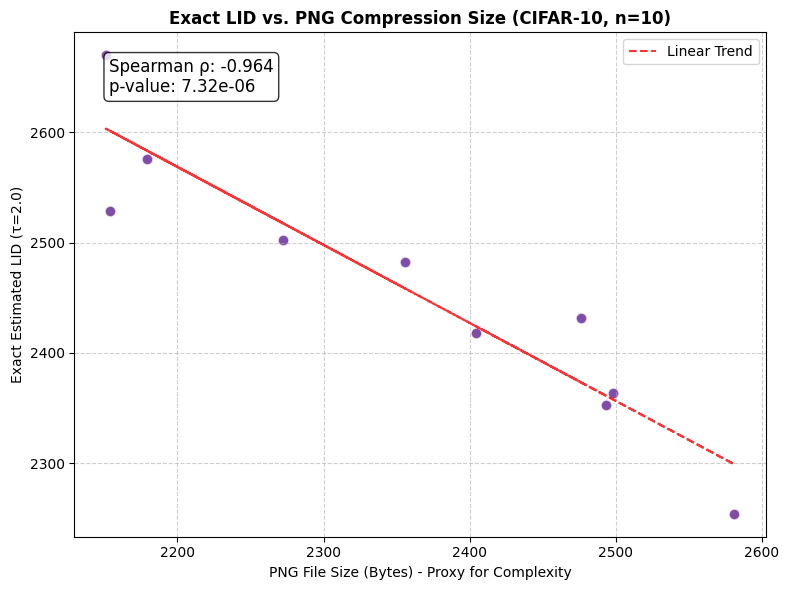

In [ ]:
import os
import glob
import io
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from scipy.stats import spearmanr
from tqdm import tqdm

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = False # T4 (Turing) does not support TF32

# from network_transformer_vit import EBViTModelWrapper

class CIFAR10ModelConfig:
    num_channels = 128
    num_res_blocks = 2
    energy_clamp = None
    num_heads = 4
    num_head_channels = 64
    dropout = 0.1
    attention_resolutions = "16"
    embed_dim = 384
    transformer_nheads = 4
    transformer_nlayers = 8
    output_scale = 1000.0
    channel_mult = [1, 2, 2, 2]

def build_model(config, device):
    model = EBViTModelWrapper(
        dim=(3, 32, 32),
        num_channels=config.num_channels,
        num_res_blocks=config.num_res_blocks,
        channel_mult=config.channel_mult,
        attention_resolutions=config.attention_resolutions,
        num_heads=config.num_heads,
        num_head_channels=config.num_head_channels,
        dropout=config.dropout,
        output_scale=config.output_scale,
        energy_clamp=config.energy_clamp,
        patch_size=4,
        embed_dim=config.embed_dim,
        transformer_nheads=config.transformer_nheads,
        transformer_nlayers=config.transformer_nlayers,
    ).to(device)

    model.eval()

    for param in model.parameters():
        param.requires_grad = False

    return model

def load_checkpoint(model, ckpt_path, device, use_ema=True):
    ckpt = torch.load(ckpt_path, map_location=device)
    key = "ema_model" if use_ema else "net_model"
    model.load_state_dict(ckpt[key], strict=True)
    return model

def get_png_size(pil_img):
    img_byte_arr = io.BytesIO()
    pil_img.save(img_byte_arr, format='PNG')
    return len(img_byte_arr.getvalue())

def load_cifar_images(folder_path, device, max_images=100):
    search_pattern = os.path.join(folder_path, "*.[pP][nN][gG]")
    image_paths = glob.glob(search_pattern) + glob.glob(os.path.join(folder_path, "*.[jJ][pP][gG]"))

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    data = []
    for path in image_paths[:max_images]:
        img = Image.open(path).convert('RGB')
        png_size = get_png_size(img)
        img_tensor = transform(img).unsqueeze(0).to(device)

        data.append({
            "filename": os.path.basename(path),
            "tensor": img_tensor,
            "png_size": png_size
        })
    return data

def compute_exact_lid_silent(model, image_tensor, device, tau=2.0):
    _, C, H, W = image_tensor.shape
    d = C * H * W
    x_flat = image_tensor.view(-1).clone().detach().requires_grad_(True)

    def energy_fn(x_in):
        t_dummy = torch.zeros(1, device=device)
        v_out = model(t_dummy, x_in.view(1, C, H, W), return_potential=True)
        return v_out.sum()

    with torch.nn.attention.sdpa_kernel([torch.nn.attention.SDPBackend.MATH]):
        hessian_matrix = torch.autograd.functional.hessian(energy_fn, x_flat, vectorize=False)

    eigenvalues, _ = torch.linalg.eigh(hessian_matrix)
    eigenvalues = eigenvalues.detach().cpu().numpy()

    near_zero_mask = np.abs(eigenvalues) <= tau
    k = np.sum(near_zero_mask)
    lid = d - k
    # lid = int(np.sum(near_zero_mask))

    return lid


if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    CHECKPOINT_PATH = "/content/drive/MyDrive/Colab Notebooks/Genmod/cifar10_checkpoint_final.pt"
    IMAGES_FOLDER = "./cifar10_figures"

    TAU_CIFAR = 2.0
    NUM_IMAGES_TO_TEST = 50

    config = CIFAR10ModelConfig()
    model = build_model(config, device)
    model = load_checkpoint(model, CHECKPOINT_PATH, device, use_ema=True)

    print(f"\nLoading up to {NUM_IMAGES_TO_TEST} images...")
    dataset = load_cifar_images(IMAGES_FOLDER, device, max_images=NUM_IMAGES_TO_TEST)

    if len(dataset) < 3:
        print("Not enough images found. Exiting.")
        exit()

    lids = []
    png_sizes = []

    print(f"\nComputing EXACT LIDs for {len(dataset)} images (Optimized for T4)...")

    for item in tqdm(dataset, desc="Processing Images", unit="img"):
        lid = compute_exact_lid_silent(model, item["tensor"], device, tau=TAU_CIFAR)
        lids.append(lid)
        png_sizes.append(item["png_size"])

    correlation, p_value = spearmanr(lids, png_sizes)
    print("\n" + "="*50)
    print(f"Evaluated Images: {len(dataset)}")
    print(f"Spearman's Correlation (\u03c1): {correlation:.4f}")
    print(f"p-value: {p_value:.4e}")
    print("="*50)

    plt.figure(figsize=(8, 6))
    plt.scatter(png_sizes, lids, alpha=0.7, color='indigo', edgecolors='w', s=60)

    z = np.polyfit(png_sizes, lids, 1)
    p = np.poly1d(z)
    plt.plot(png_sizes, p(png_sizes), "r--", alpha=0.8, label="Linear Trend")

    plt.title(f"Exact LID vs. PNG Compression Size (CIFAR-10, n={len(dataset)})", fontweight='bold')
    plt.xlabel("PNG File Size (Bytes) - Proxy for Complexity")
    plt.ylabel(f"Exact Estimated LID (\u03c4={TAU_CIFAR})")
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.text(0.05, 0.95, f"Spearman \u03c1: {correlation:.3f}\np-value: {p_value:.2e}",
             transform=plt.gca().transAxes,
             fontsize=12,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.legend()
    plt.tight_layout()
    plt.show()

Using device: cuda

Loading up to 50 images...

Computing EXACT LIDs for 10 images (Optimized for T4)...


Processing Images: 100%|██████████| 10/10 [1:02:30<00:00, 375.10s/img]


Evaluated Images: 10
Spearman's Correlation (ρ): 0.9636
p-value: 7.3210e-06


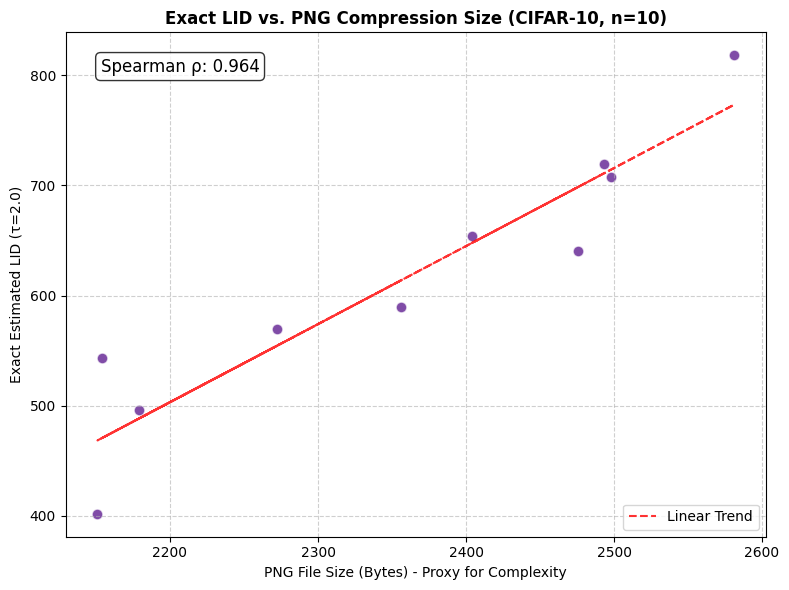

In [ ]:
import os
import glob
import io
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from scipy.stats import spearmanr
from tqdm import tqdm

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = False # T4 (Turing) does not support TF32

# from network_transformer_vit import EBViTModelWrapper

class CIFAR10ModelConfig:
    num_channels = 128
    num_res_blocks = 2
    energy_clamp = None
    num_heads = 4
    num_head_channels = 64
    dropout = 0.1
    attention_resolutions = "16"
    embed_dim = 384
    transformer_nheads = 4
    transformer_nlayers = 8
    output_scale = 1000.0
    channel_mult = [1, 2, 2, 2]

def build_model(config, device):
    model = EBViTModelWrapper(
        dim=(3, 32, 32),
        num_channels=config.num_channels,
        num_res_blocks=config.num_res_blocks,
        channel_mult=config.channel_mult,
        attention_resolutions=config.attention_resolutions,
        num_heads=config.num_heads,
        num_head_channels=config.num_head_channels,
        dropout=config.dropout,
        output_scale=config.output_scale,
        energy_clamp=config.energy_clamp,
        patch_size=4,
        embed_dim=config.embed_dim,
        transformer_nheads=config.transformer_nheads,
        transformer_nlayers=config.transformer_nlayers,
    ).to(device)

    model.eval()

    for param in model.parameters():
        param.requires_grad = False

    return model

def load_checkpoint(model, ckpt_path, device, use_ema=True):
    ckpt = torch.load(ckpt_path, map_location=device)
    key = "ema_model" if use_ema else "net_model"
    model.load_state_dict(ckpt[key], strict=True)
    return model

def get_png_size(pil_img):
    img_byte_arr = io.BytesIO()
    pil_img.save(img_byte_arr, format='PNG')
    return len(img_byte_arr.getvalue())

def load_cifar_images(folder_path, device, max_images=100):
    search_pattern = os.path.join(folder_path, "*.[pP][nN][gG]")
    image_paths = glob.glob(search_pattern) + glob.glob(os.path.join(folder_path, "*.[jJ][pP][gG]"))

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    data = []
    for path in image_paths[:max_images]:
        img = Image.open(path).convert('RGB')
        png_size = get_png_size(img)
        img_tensor = transform(img).unsqueeze(0).to(device)

        data.append({
            "filename": os.path.basename(path),
            "tensor": img_tensor,
            "png_size": png_size
        })
    return data

def compute_exact_lid_silent(model, image_tensor, device, tau=2.0):
    _, C, H, W = image_tensor.shape
    d = C * H * W
    x_flat = image_tensor.view(-1).clone().detach().requires_grad_(True)

    def energy_fn(x_in):
        t_dummy = torch.zeros(1, device=device)
        v_out = model(t_dummy, x_in.view(1, C, H, W), return_potential=True)
        return v_out.sum()

    with torch.nn.attention.sdpa_kernel([torch.nn.attention.SDPBackend.MATH]):
        hessian_matrix = torch.autograd.functional.hessian(energy_fn, x_flat, vectorize=False)

    eigenvalues, _ = torch.linalg.eigh(hessian_matrix)
    eigenvalues = eigenvalues.detach().cpu().numpy()

    near_zero_mask = np.abs(eigenvalues) <= tau
    # k = np.sum(near_zero_mask)
    # lid = d - k
    lid = int(np.sum(near_zero_mask))

    return lid

# ==========================================
# Execution Flow
# ==========================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    CHECKPOINT_PATH = "/content/drive/MyDrive/Colab Notebooks/Genmod/cifar10_checkpoint_final.pt"
    IMAGES_FOLDER = "./cifar10_figures"

    TAU_CIFAR = 2.0
    NUM_IMAGES_TO_TEST = 50

    config = CIFAR10ModelConfig()
    model = build_model(config, device)
    model = load_checkpoint(model, CHECKPOINT_PATH, device, use_ema=True)

    print(f"\nLoading up to {NUM_IMAGES_TO_TEST} images...")
    dataset = load_cifar_images(IMAGES_FOLDER, device, max_images=NUM_IMAGES_TO_TEST)

    if len(dataset) < 3:
        print("Not enough images found. Exiting.")
        exit()

    lids = []
    png_sizes = []

    print(f"\nComputing EXACT LIDs for {len(dataset)} images (Optimized for T4)...")

    for item in tqdm(dataset, desc="Processing Images", unit="img"):
        lid = compute_exact_lid_silent(model, item["tensor"], device, tau=TAU_CIFAR)
        lids.append(lid)
        png_sizes.append(item["png_size"])

    correlation, p_value = spearmanr(lids, png_sizes)
    print("\n" + "="*50)
    print(f"Evaluated Images: {len(dataset)}")
    print(f"Spearman's Correlation (\u03c1): {correlation:.4f}")
    print(f"p-value: {p_value:.4e}")
    print("="*50)

    plt.figure(figsize=(8, 6))
    plt.scatter(png_sizes, lids, alpha=0.7, color='indigo', edgecolors='w', s=60)

    z = np.polyfit(png_sizes, lids, 1)
    p = np.poly1d(z)
    plt.plot(png_sizes, p(png_sizes), "r--", alpha=0.8, label="Linear Trend")

    plt.title(f"Exact LID vs. PNG Compression Size (CIFAR-10, n={len(dataset)})", fontweight='bold')
    plt.xlabel("PNG File Size (Bytes) - Proxy for Complexity")
    plt.ylabel(f"Exact Estimated LID (\u03c4={TAU_CIFAR})")
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.text(0.05, 0.95, f"Spearman \u03c1: {correlation:.3f}",
             transform=plt.gca().transAxes,
             fontsize=12,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.legend()
    plt.tight_layout()
    plt.show()

Using device: cuda
Folder './mnist_exact_figures' already has images. Skipping download.

Computing EXACT LIDs for 10 images...
Note: This performs 3072 backward passes per image. Please be patient.


Processing Images: 100%|██████████| 10/10 [42:02<00:00, 252.23s/img]


Evaluated Images: 10
Spearman's Correlation (ρ): 0.8182
p-value: 3.8149e-03


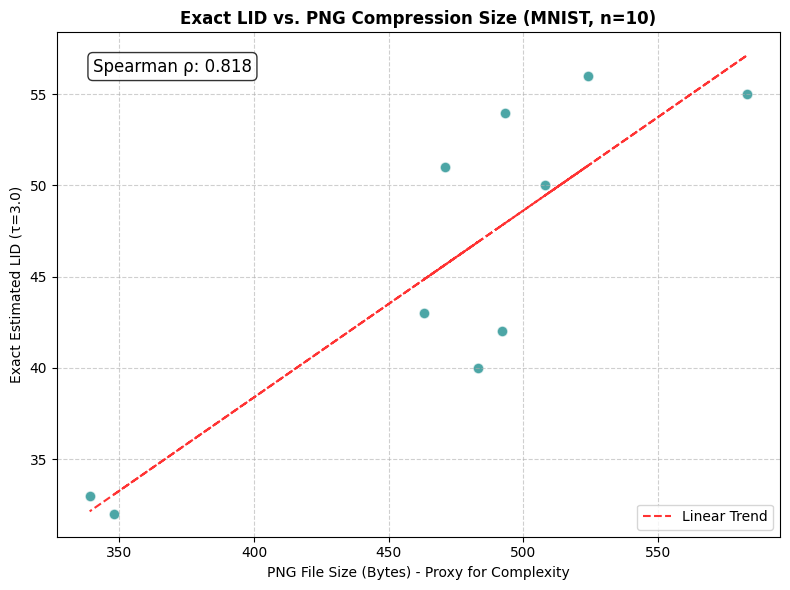

In [ ]:
import os
import glob
import io
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.utils import save_image
from scipy.stats import spearmanr
from tqdm import tqdm

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = False

# from network_transformer_vit import EBViTModelWrapper

class MNISTModelConfig:
    num_channels = 32
    num_res_blocks = 2
    energy_clamp = None
    num_heads = 2
    num_head_channels = 64
    dropout = 0.1
    attention_resolutions = "16"
    embed_dim = 128
    transformer_nheads = 2
    transformer_nlayers = 2
    output_scale = 100.0
    channel_mult = [1, 2, 2]

def setup_mnist_folder(output_dir="./mnist_exact_figures", num_images=10):
    if os.path.exists(output_dir) and len(os.listdir(output_dir)) >= num_images:
        print(f"Folder '{output_dir}' already has images. Skipping download.")
        return

    os.makedirs(output_dir, exist_ok=True)
    print("Downloading and preparing the MNIST dataset...")

    download_transform = transforms.Compose([
        transforms.Pad(2),
        transforms.ToTensor()
    ])

    mnist_data = torchvision.datasets.MNIST(
        root='./data',
        train=False,
        download=True,
        transform=download_transform
    )

    print(f"Saving {num_images} images to '{output_dir}' as PNGs...")
    for i in range(min(num_images, len(mnist_data))):
        image_tensor, label = mnist_data[i]
        filename = os.path.join(output_dir, f"mnist_{i:04d}_label_{label}.png")
        save_image(image_tensor, filename)

def build_model(config, device):
    model = EBViTModelWrapper(
        dim=(3, 32, 32),
        num_channels=config.num_channels,
        num_res_blocks=config.num_res_blocks,
        channel_mult=config.channel_mult,
        attention_resolutions=config.attention_resolutions,
        num_heads=config.num_heads,
        num_head_channels=config.num_head_channels,
        dropout=config.dropout,
        output_scale=config.output_scale,
        energy_clamp=config.energy_clamp,
        patch_size=4,
        embed_dim=config.embed_dim,
        transformer_nheads=config.transformer_nheads,
        transformer_nlayers=config.transformer_nlayers,
    ).to(device)

    model.eval()

    for param in model.parameters():
        param.requires_grad = False

    return model

def load_checkpoint(model, ckpt_path, device, use_ema=True):
    ckpt = torch.load(ckpt_path, map_location=device)
    key = "ema_model" if use_ema else "net_model"
    model.load_state_dict(ckpt[key], strict=True)
    return model

def get_png_size(pil_img):
    img_byte_arr = io.BytesIO()
    pil_img.save(img_byte_arr, format='PNG')
    return len(img_byte_arr.getvalue())

def load_images_for_eval(folder_path, device, max_images=10):
    search_pattern = os.path.join(folder_path, "*.[pP][nN][gG]")
    image_paths = glob.glob(search_pattern) + glob.glob(os.path.join(folder_path, "*.[jJ][pP][gG]"))

    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    data = []
    for path in image_paths[:max_images]:
        img = Image.open(path).convert('RGB')
        png_size = get_png_size(img)
        img_tensor = transform(img).unsqueeze(0).to(device)

        data.append({
            "filename": os.path.basename(path),
            "tensor": img_tensor,
            "png_size": png_size
        })
    return data

def compute_exact_lid_silent(model, image_tensor, device, tau=3.0):
    _, C, H, W = image_tensor.shape
    x_flat = image_tensor.view(-1).clone().detach().requires_grad_(True)

    def energy_fn(x_in):
        t_dummy = torch.zeros(1, device=device)
        v_out = model(t_dummy, x_in.view(1, C, H, W), return_potential=True)
        return v_out.sum()

    with torch.nn.attention.sdpa_kernel([torch.nn.attention.SDPBackend.MATH]):
        hessian_matrix = torch.autograd.functional.hessian(energy_fn, x_flat, vectorize=False)

    eigenvalues, _ = torch.linalg.eigh(hessian_matrix)
    eigenvalues = eigenvalues.detach().cpu().numpy()

    near_zero_mask = np.abs(eigenvalues) <= tau
    lid = int(np.sum(near_zero_mask))

    return lid


if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    CHECKPOINT_PATH = '/content/drive/MyDrive/Colab Notebooks/Genmod/checkpoint_50400.pt'
    IMAGES_FOLDER = "./mnist_exact_figures"

    TAU_MNIST = 3.0       # 2.0
    NUM_IMAGES = 10

    setup_mnist_folder(output_dir=IMAGES_FOLDER, num_images=NUM_IMAGES)

    config = MNISTModelConfig()
    model = build_model(config, device)
    model = load_checkpoint(model, CHECKPOINT_PATH, device, use_ema=True)

    dataset = load_images_for_eval(IMAGES_FOLDER, device, max_images=NUM_IMAGES)

    lids = []
    png_sizes = []

    print(f"\nComputing EXACT LIDs for {len(dataset)} images...")
    print("Note: This performs 3072 backward passes per image. Please be patient.")

    for item in tqdm(dataset, desc="Processing Images", unit="img"):
        lid = compute_exact_lid_silent(model, item["tensor"], device, tau=TAU_MNIST)
        lids.append(lid)
        png_sizes.append(item["png_size"])

    correlation, p_value = spearmanr(lids, png_sizes)
    print("\n" + "="*50)
    print(f"Evaluated Images: {len(dataset)}")
    print(f"Spearman's Correlation (\u03c1): {correlation:.4f}")
    print(f"p-value: {p_value:.4e}")
    print("="*50)

    plt.figure(figsize=(8, 6))
    plt.scatter(png_sizes, lids, alpha=0.7, color='teal', edgecolors='w', s=60)

    if len(png_sizes) > 1:
        z = np.polyfit(png_sizes, lids, 1)
        p = np.poly1d(z)
        plt.plot(png_sizes, p(png_sizes), "r--", alpha=0.8, label="Linear Trend")

    plt.title(f"Exact LID vs. PNG Compression Size (MNIST, n={len(dataset)})", fontweight='bold')
    plt.xlabel("PNG File Size (Bytes) - Proxy for Complexity")
    plt.ylabel(f"Exact Estimated LID (\u03c4={TAU_MNIST})")
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.text(0.05, 0.95, f"Spearman \u03c1: {correlation:.3f}",
             transform=plt.gca().transAxes,
             fontsize=12,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.legend()
    plt.tight_layout()
    plt.show()